In [1]:
import torch
import nibabel as nib
import numpy as np
import sys
import glob
from natsort import natsorted
# import matplotlib.pyplot as plt
sys.path.append("../src")
from segment2d import *
from omegaconf import DictConfig, OmegaConf
import hydra
import matplotlib.pyplot as plt

In [2]:
list_image = natsorted(glob.glob("../data/CMR-MULTI/LGE_MULTI/SAX_TR/image/*"))[:2]

count_z = 0
print(f"Total number of images: {len(list_image)}")
for i in range(len(list_image)):

    image = nib.load(list_image[i])
    array_image = image.get_fdata()
    # mask = nib.load(list_mask[i])
    # array_mask = mask.get_fdata().astype(np.int32)
    # find class weight for each class by dividing the total number of pixels by the number of pixels in each class
    count_z += array_image.shape[2]
print(f"Total number of pixels in all images: {count_z}")

Total number of images: 2
Total number of pixels in all images: 20


In [3]:
preprocess = min_max_normalize(array_image, cmr_type="cine")

In [4]:
array_image.min(), array_image.max()

(np.float64(-510.24786376953125), np.float64(2715.296875))

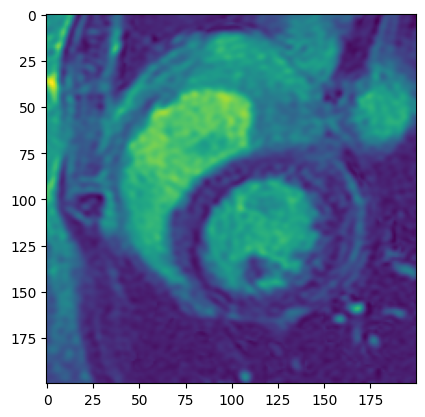

In [5]:
array_image.min(), array_image.max()
plt.imshow(array_image[:, :, 5])

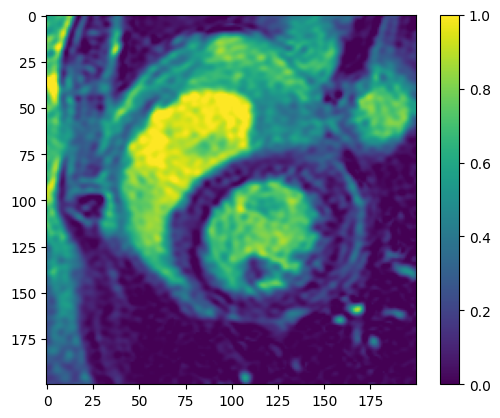

In [7]:
plt.imshow(preprocess[:, :, 5],)
plt.colorbar()

In [118]:
cfg_data = OmegaConf.load("../config/data_config.yaml")

num_classes_dict = {k: cfg_data.CMR_MULTI.CINE_MULTI[k].num_classes for k in cfg_data.CMR_MULTI.CINE_MULTI.keys()}
class_weights_dict = {k: cfg_data.CMR_MULTI.CINE_MULTI[k].class_weights for k in cfg_data.CMR_MULTI.CINE_MULTI.keys()}

In [62]:
sax_files = natsorted(glob.glob("../data/CMR-MULTI_npz/CINE_MULTI/SAX/*"))[:12]
ch2_files = natsorted(glob.glob("../data/CMR-MULTI_npz/CINE_MULTI/2CH/*"))[:12]
ch4_files = natsorted(glob.glob("../data/CMR-MULTI_npz/CINE_MULTI/4CH/*"))[:12]


files_dict = {
    "SAX": sax_files,
    "2CH": ch2_files,
    "4CH": ch4_files,
}

dataset = MultiViewDataset(files_dict)
batch_sampler = SingleViewBatchSampler(dataset, batch_size=4)

loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=4)
data = iter(loader)

In [68]:
image, mask, view = next(data)
view

('4CH', '4CH', '4CH', '4CH')

In [10]:
model = MultiHeadFCDenseNet(
    in_channels=1,
    head_classes={
        "SAX": 4,
        "2CH": 3,
        "4CH": 6,
    },
)

x = torch.randn(2, 1, 256, 256)

y_sax = model(x, view="4CH")
print(y_sax.shape)  # [2, 4, 256, 256]

torch.Size([2, 6, 256, 256])


In [ ]:
# list_mask = natsorted(glob.glob("../data/CMR-MULTI/LGE_MULTI/RAS_TR/anno/*"))

# # count the number of pixels in each class in all masks in all images
# class_counts = {}
# for i in range(len(list_image)):

#     # image = nib.load(list_image[i])
#     # array_image = image.get_fdata()
#     mask = nib.load(list_mask[i])
#     array_mask = mask.get_fdata().astype(np.int32)
#     # find class weight for each class by dividing the total number of pixels by the number of pixels in each class
#     for class_index in np.unique(array_mask):
#         if class_index not in class_counts:
#             class_counts[class_index] = 0
#         class_counts[class_index] += np.sum(array_mask == class_index)
    
# # calculate class weight by divide the number of pixel 0
# class_weights = {}
# for class_index, count in class_counts.items():
#     class_weights[class_index] = (class_counts[0] / count).astype(np.float32)


# class_weights

{np.int32(0): np.float32(1.0), np.int32(1): np.float32(21.95373)}

In [14]:
import numpy as np
import matplotlib.pyplot as plt
data = np.load("/home/nhattm/CMR-MULTI/data/CMR-MULTI_npz/LGE_MULTI/SAX/LGE_SAX_001_4.npz")
image, mask = data["image"], data["mask"]

In [17]:
image.min(), image.max()

(np.float64(0.11122369935393116), np.float64(0.9556950841557093))

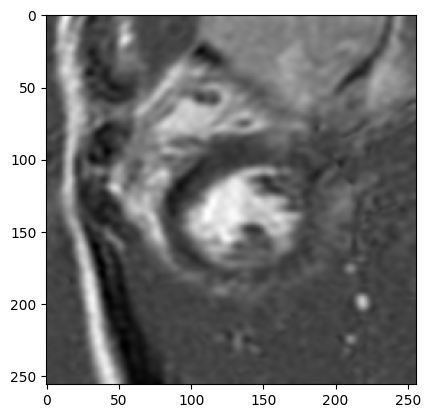

In [16]:
plt.imshow(image[:, :, 0], cmap="gray")
# plt.imshow(array_mask[:,:,0], alpha=0.5)

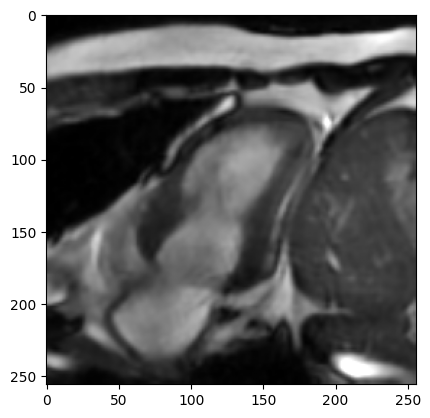

In [147]:
plt.imshow(crop_image[..., 50], cmap="gray")
# plt.imshow(crop_mask[:, :, 0], alpha=0.5)